In [1]:
from functools import partial
import pickle
from omegaconf import OmegaConf

import jax
import jax.numpy as jnp
import mediapy

key = jax.random.PRNGKey(0)

In [2]:
from omni_epic.envs.avoid_flying_boxes import Env
from ppo.wrappers import (
	EpisodeWrapper,
	AutoResetWrapper,
	LogWrapper,
	ClipAction,
	VecEnv,
	NormalizeVecObservation,
	NormalizeVecReward,
)

env = Env()
# env = EpisodeWrapper(env, episode_length=1000, action_repeat=1)
# env = AutoResetWrapper(env)
# env = LogWrapper(env)
# env = ClipAction(env)
# env = VecEnv(env)
# env = NormalizeVecObservation(env)
# env = NormalizeVecReward(env, 0.99)

In [3]:
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

num_envs = 16

In [4]:
key, subkey = jax.random.split(key)
env_state = reset_fn(subkey)
images = [env.renderer(env_state)]
for _ in range(200):
	action = jnp.zeros(4)
	# action = action.at[0].set(0.2)
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)
	images.append(env.renderer(env_state))

In [5]:
mediapy.show_video(images)

This browser does not support the video tag.


: 

In [4]:
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num_envs)
env_state = reset_fn(keys)
env_states = [env_state]
for _ in range(200):
	action = jnp.zeros((num_envs, 4))
	# action = action.at[0].set(0.2)
	key, subkey = jax.random.split(key)
	keys = jax.random.split(subkey, num_envs)
	env_state = step_fn(keys, env_state, action)
	env_states.append(env_state)

# # Move robot
# env_state = env.set_polygon_position(env_state, env.robot_idx, jnp.array([10.0, 10.0]))

# for _ in range(10):
# 	action = jnp.zeros(4)
# 	key, subkey = jax.random.split(key)
# 	env_state = step_fn(subkey, env_state, action)
# 	images.append(env.renderer(env_state))
# 	print(_, env_state.terminated)

# for _ in range(200):
# 	action = jnp.zeros(4)
# 	# action = -action.at[3].set(0.2)
# 	key, subkey = jax.random.split(key)
# 	env_state = step_fn(subkey, env_state, action)
# 	images.append(env.renderer(env_state))
# 	print(_, env_state.terminated)

In [5]:
mediapy.show_video([env_state.observation["image"][3] for env_state in env_states])

In [6]:
mediapy.show_video([env_state.observation["image"][3] for env_state in env_states])

In [7]:
mediapy.show_video([env_state.observation["image"][3] for env_state in env_states])

: 

""

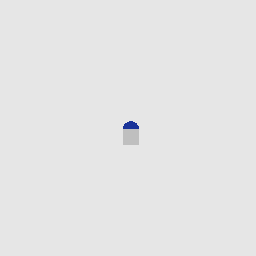

In [28]:
mediapy.show_image(env_states[0].observation["image"][1])

## Evaluate PPO

In [2]:
from ppo.ppo import ActorCritic
from ppo.wrappers import Jax2DWrapper

run_path = "/workdir/output/ppo/2024-11-20_191401_833762"
config = OmegaConf.load(f"{run_path}/.hydra/config.yaml")

env = Jax2DWrapper(config.env_path)

params = pickle.load(open(f"{run_path}/params.pickle", "rb"))
network = ActorCritic(env.action_space.shape[0], activation=config.activation)

In [5]:
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

key, subkey = jax.random.split(key)
env_state = reset_fn(subkey)
env_states = [env_state]
for i in range(config.episode_length):
	# Act
	key, subkey = jax.random.split(key)
	pi, value = network.apply(params, env_state.observation["vector"])
	action = pi.sample(seed=subkey)

	# Step
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)

	env_states.append(env_state)

In [6]:
mediapy.show_video([env_state.observation["image"] for env_state in env_states])

This browser does not support the video tag.


## Check collisions

In [ ]:
state = env.reset(None)
action = jnp.zeros(env.static_sim_params.num_joints + env.static_sim_params.num_thrusters)
current_state, manifolds = env.step_fn(state, env.sim_params, action)
env.collision_pp(manifolds, env.robot_idx, env.obstacle_idx)